In [ ]:
import scanpy as sc
import STCOGAT
from STCOGAT.Utils import *
from STCOGAT.data_preprocess import *
from matplotlib import pyplot as plt
plt.rcParams.update({'axes.titlesize': 20})
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import warnings
warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=300,fontsize=10,dpi_save=300,facecolor='white',format='pdf')
sc.settings.figdir = './Result/VISp/'
outdir = './Result/VISp/'
STCOGAT.main.INTER_DIM = 250 
STCOGAT.main.EMBEDDING_DIM = 20  
STCOGAT.main.DE_GENES_NUM = 1020
STCOGAT.main.pre_emb_dim = 14
STCOGAT.main.lambda_smooth  = 2.520377540313058
STCOGAT.main.lambda_contra = 1.5
STCOGAT.main.use_rows_encoder = True

cuda:0


In [ ]:
adata = sc.read_h5ad("./data/STARmap_20180505_BY3_1k.h5ad")   

In [ ]:
adata, adata_raw = svg(adata, svg_method='gft_top', n_top=1020)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=15)  
net, genet, node_feature = STCOGAT.build_coexpres_network(adata)
print('genet:',genet,'node_feature:',node_feature.shape)
knn_edge_index = STCOGAT.build_fused_graph(adata,alpha=0.5,k_spat=6,knn_method='KNN', prune=True)
print('Initial knn_edge_index:', knn_edge_index.shape)
STCOGAT.run_STCOGAT(adata, genet,node_feature,knn_edge_index, number_of_batches=1,max_epoch=300, model_name ="VISP",save_model_flag=True)

In [ ]:
embedded_genes, embedded_cells, node_features , out_features = STCOGAT.load_embeddings("VISP")
recon_obj = STCOGAT.create_reconstructed_obj(node_features, out_features, adata)

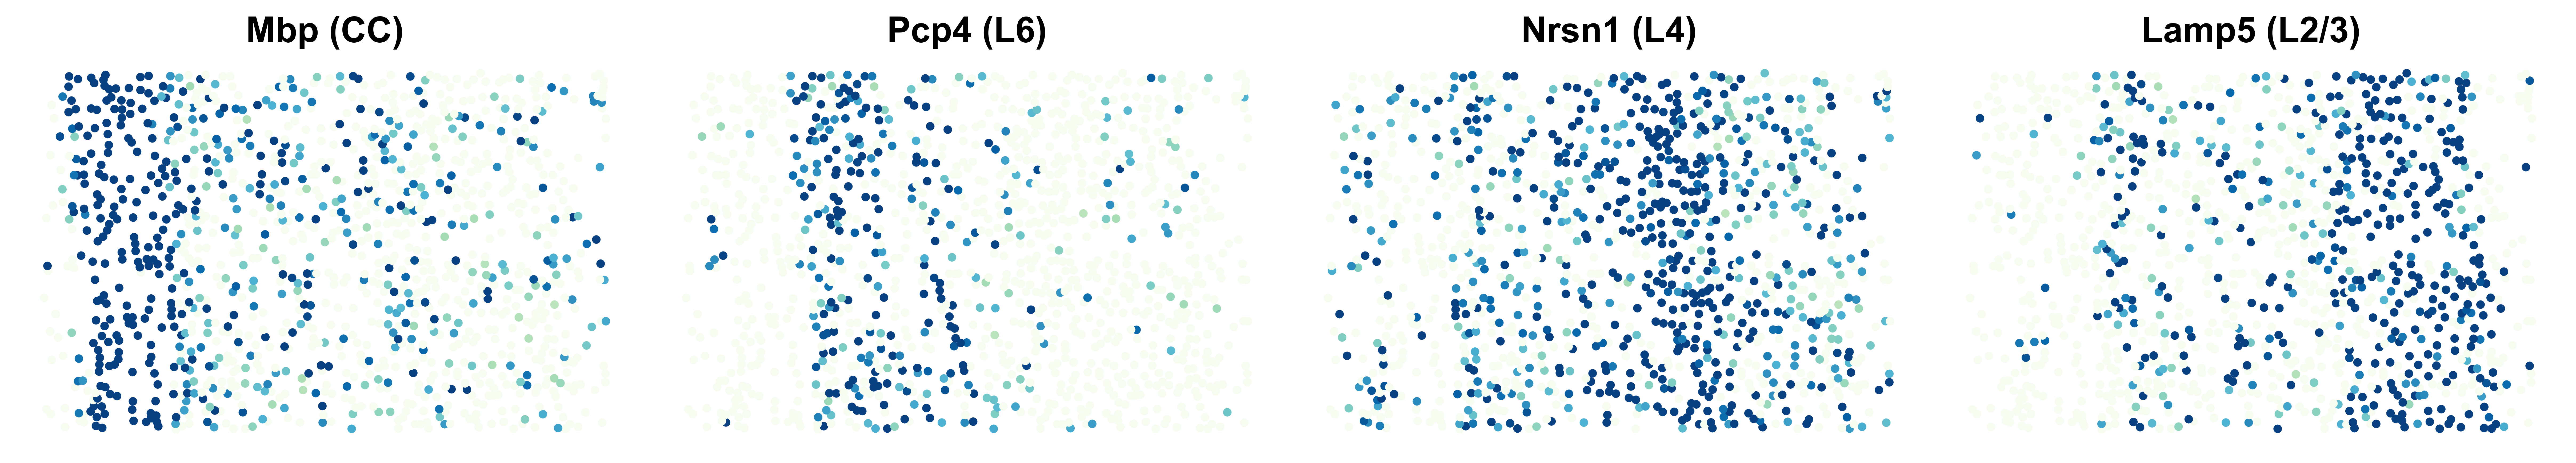

In [28]:
markers = ['Mbp','Pcp4','Nrsn1', 'Lamp5']

cell_types = ['CC','L6','L4', 'L2/3']

coords = adata_raw.obsm['spatial']
x = coords[:, 0]
y = coords[:, 1]

n_genes = len(markers)
n_cols = 4
n_rows = (n_genes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 3))

axes = axes.reshape(n_rows, n_cols)

vmin, vmax = 0, 1

for i, gene in enumerate(markers):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]

    expression = adata_raw[:, gene].X.toarray().flatten() if hasattr(adata_raw[:, gene].X, "toarray") else adata_raw[:, gene].X.flatten()

    sc2 = ax.scatter(x, y, c=expression, cmap='GnBu', s=8, vmin=vmin, vmax=vmax)
    ax.set_title(f"{gene} ({cell_types[i]})", fontsize=16, fontweight='bold')
    ax.axis('off')  
    ax.invert_yaxis()  

for j in range(n_genes, n_rows * n_cols):
    row, col = divmod(j, n_cols)
    axes[row, col].axis('off')

plt.tight_layout(rect=[0, 0, 0.9, 1]) 

plt.savefig(outdir + 'celltype-specific-genes.pdf', bbox_inches='tight')

plt.show()

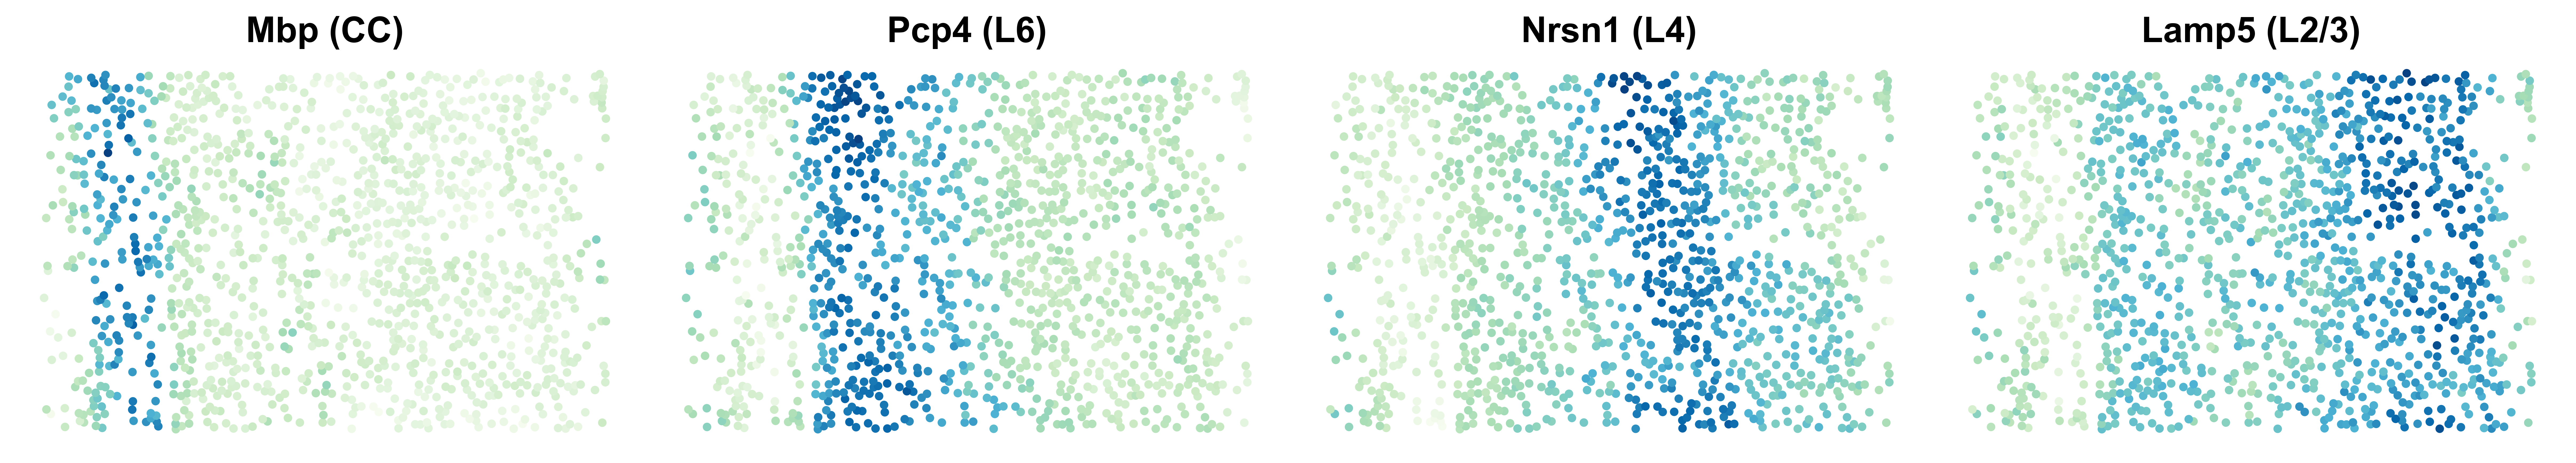

In [29]:
markers = ['Mbp','Pcp4','Nrsn1', 'Lamp5']

cell_types = ['CC','L6','L4', 'L2/3']

coords = adata_raw.obsm['spatial']
x = coords[:, 0]
y = coords[:, 1]

n_genes = len(markers)
n_cols = 4
n_rows = (n_genes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 3))

axes = axes.reshape(n_rows, n_cols)

vmin, vmax = 0, 1

for i, gene in enumerate(markers):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]

    expression = recon_obj[:, gene].X.toarray().flatten() if hasattr(recon_obj[:, gene].X, "toarray") else recon_obj[:, gene].X.flatten()

    sc2 = ax.scatter(x, y, c=expression, cmap='GnBu', s=8, vmin=vmin, vmax=vmax)
    ax.set_title(f"{gene} ({cell_types[i]})", fontsize=16, fontweight='bold')
    ax.axis('off')  
    ax.invert_yaxis()  

for j in range(n_genes, n_rows * n_cols):
    row, col = divmod(j, n_cols)
    axes[row, col].axis('off')

plt.tight_layout(rect=[0, 0, 0.9, 1]) 

plt.savefig(outdir + 'celltype-specific-genes.pdf', bbox_inches='tight')

plt.show()

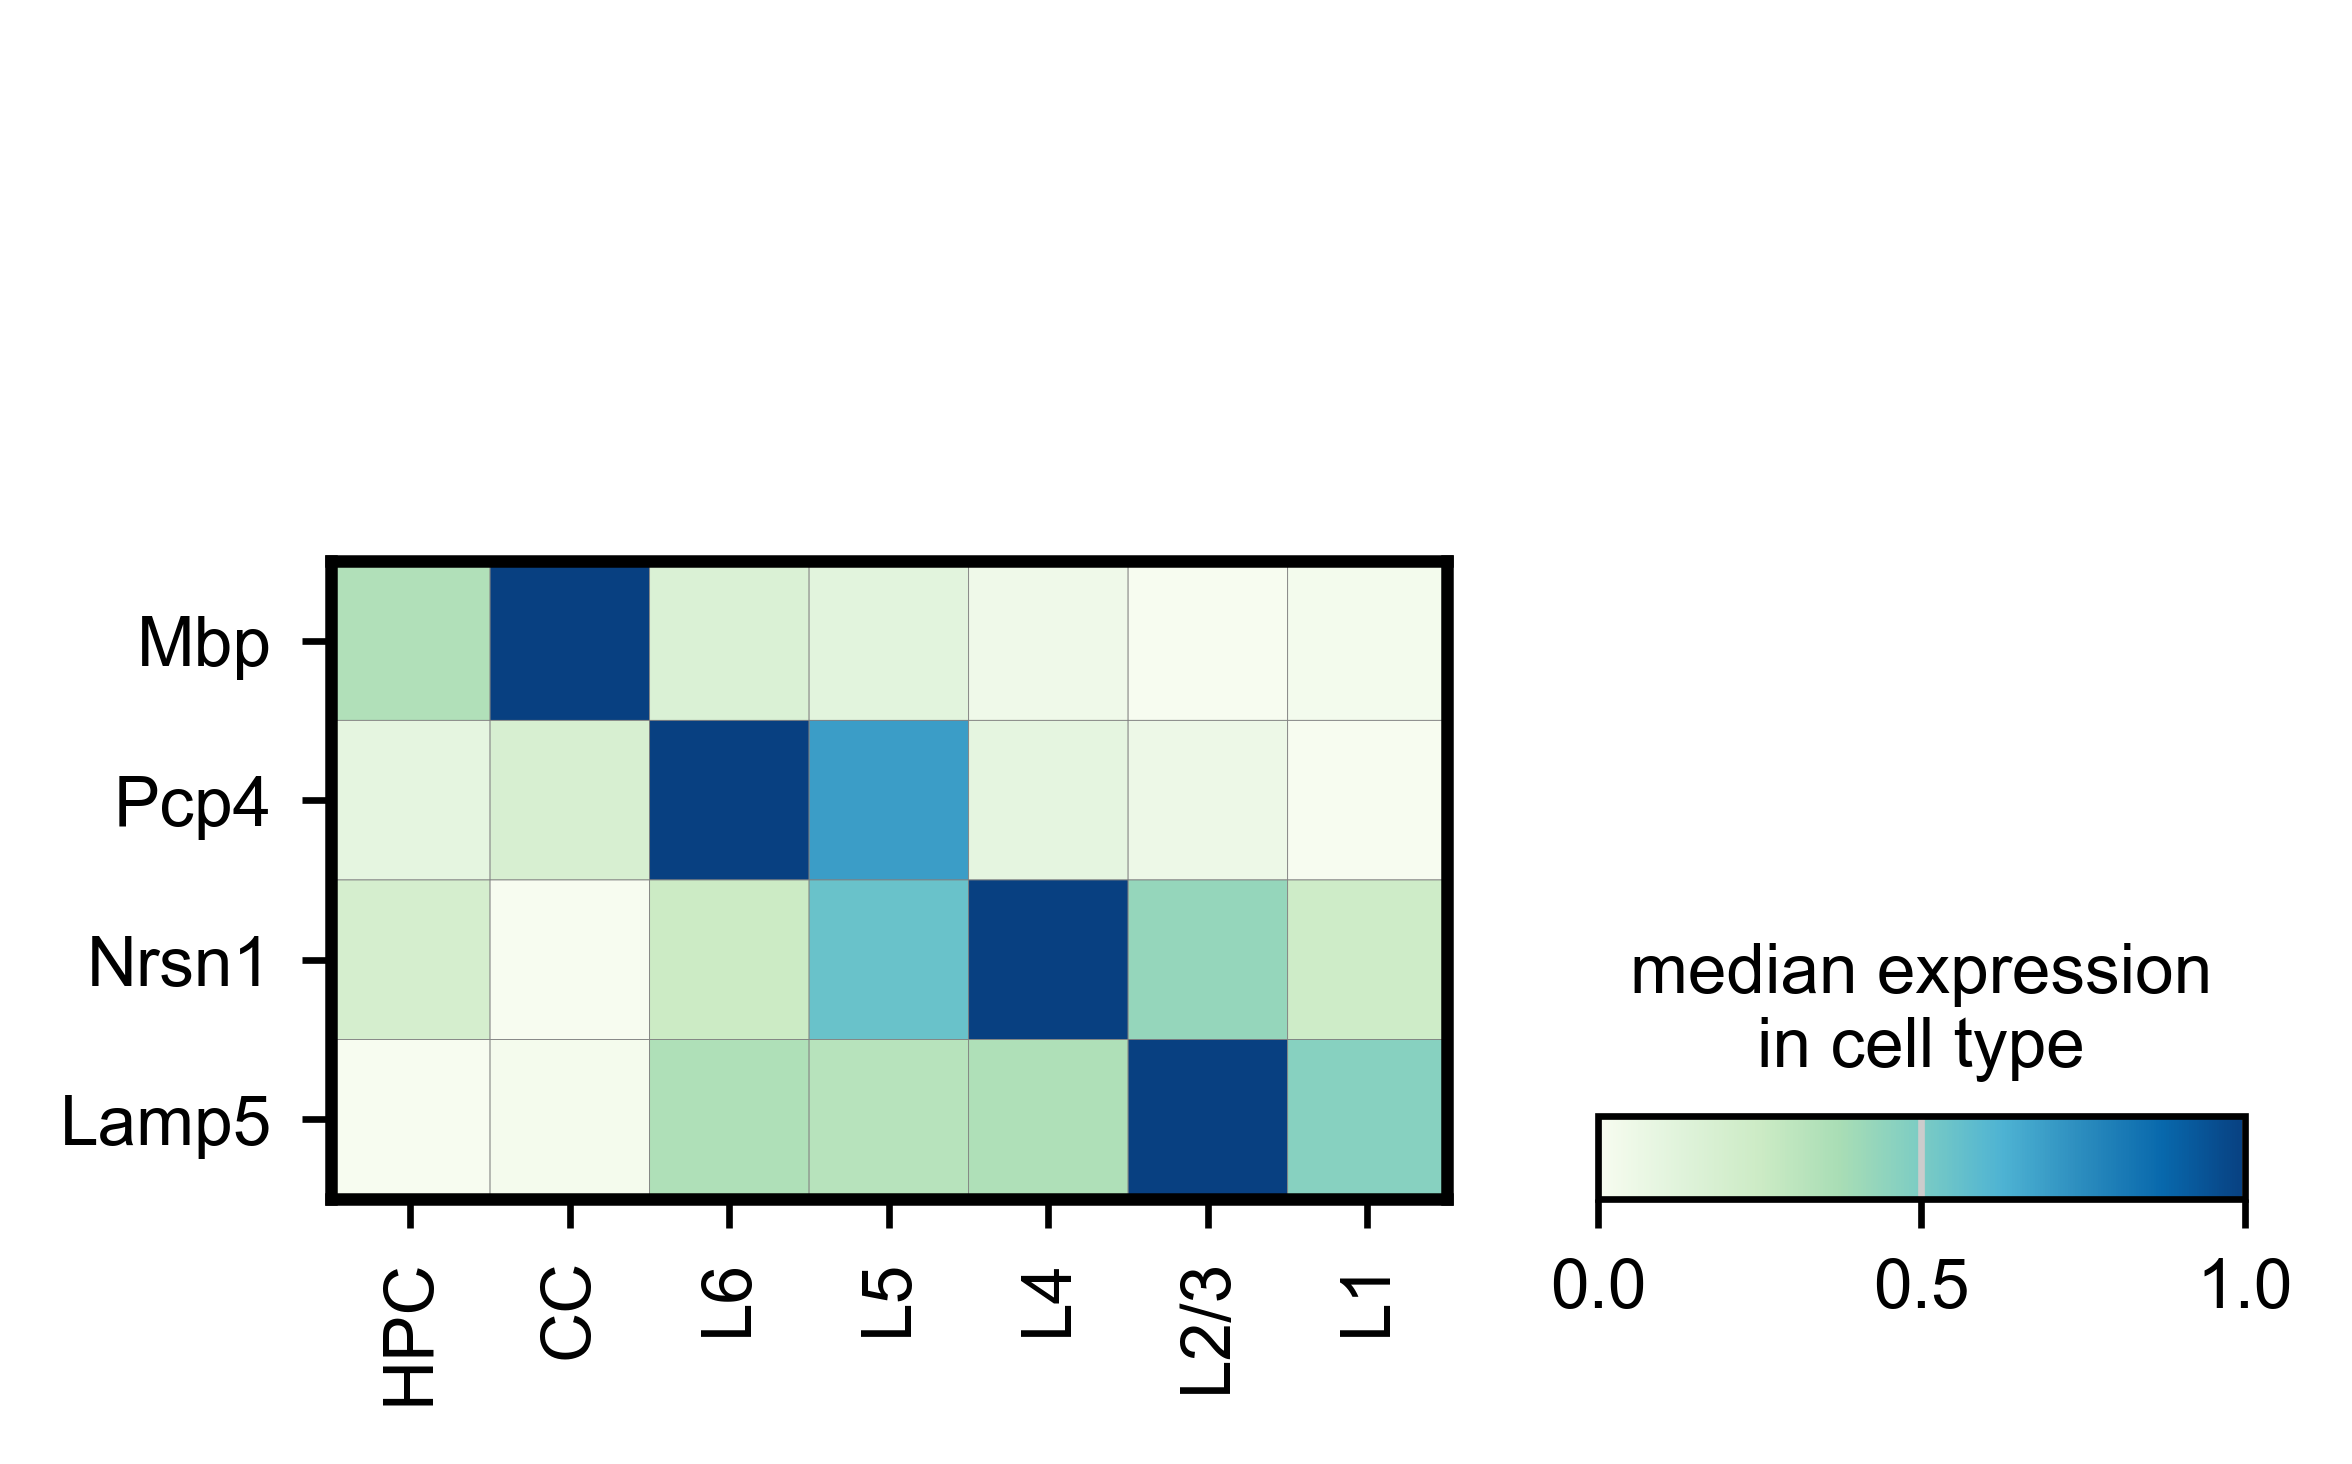

In [23]:
markers = ['Mbp','Pcp4','Nrsn1', 'Lamp5']
sc.pl.matrixplot(
    adata_raw,
    markers,
    "label",
    categories_order=['HPC','CC','L6','L5','L4', 'L2/3', 'L1'],
    dendrogram=False,
    swap_axes=True,
    cmap="GnBu",
    standard_scale="var",
    save='raw_layer_specific',
    colorbar_title='median expression\nin cell type'
)

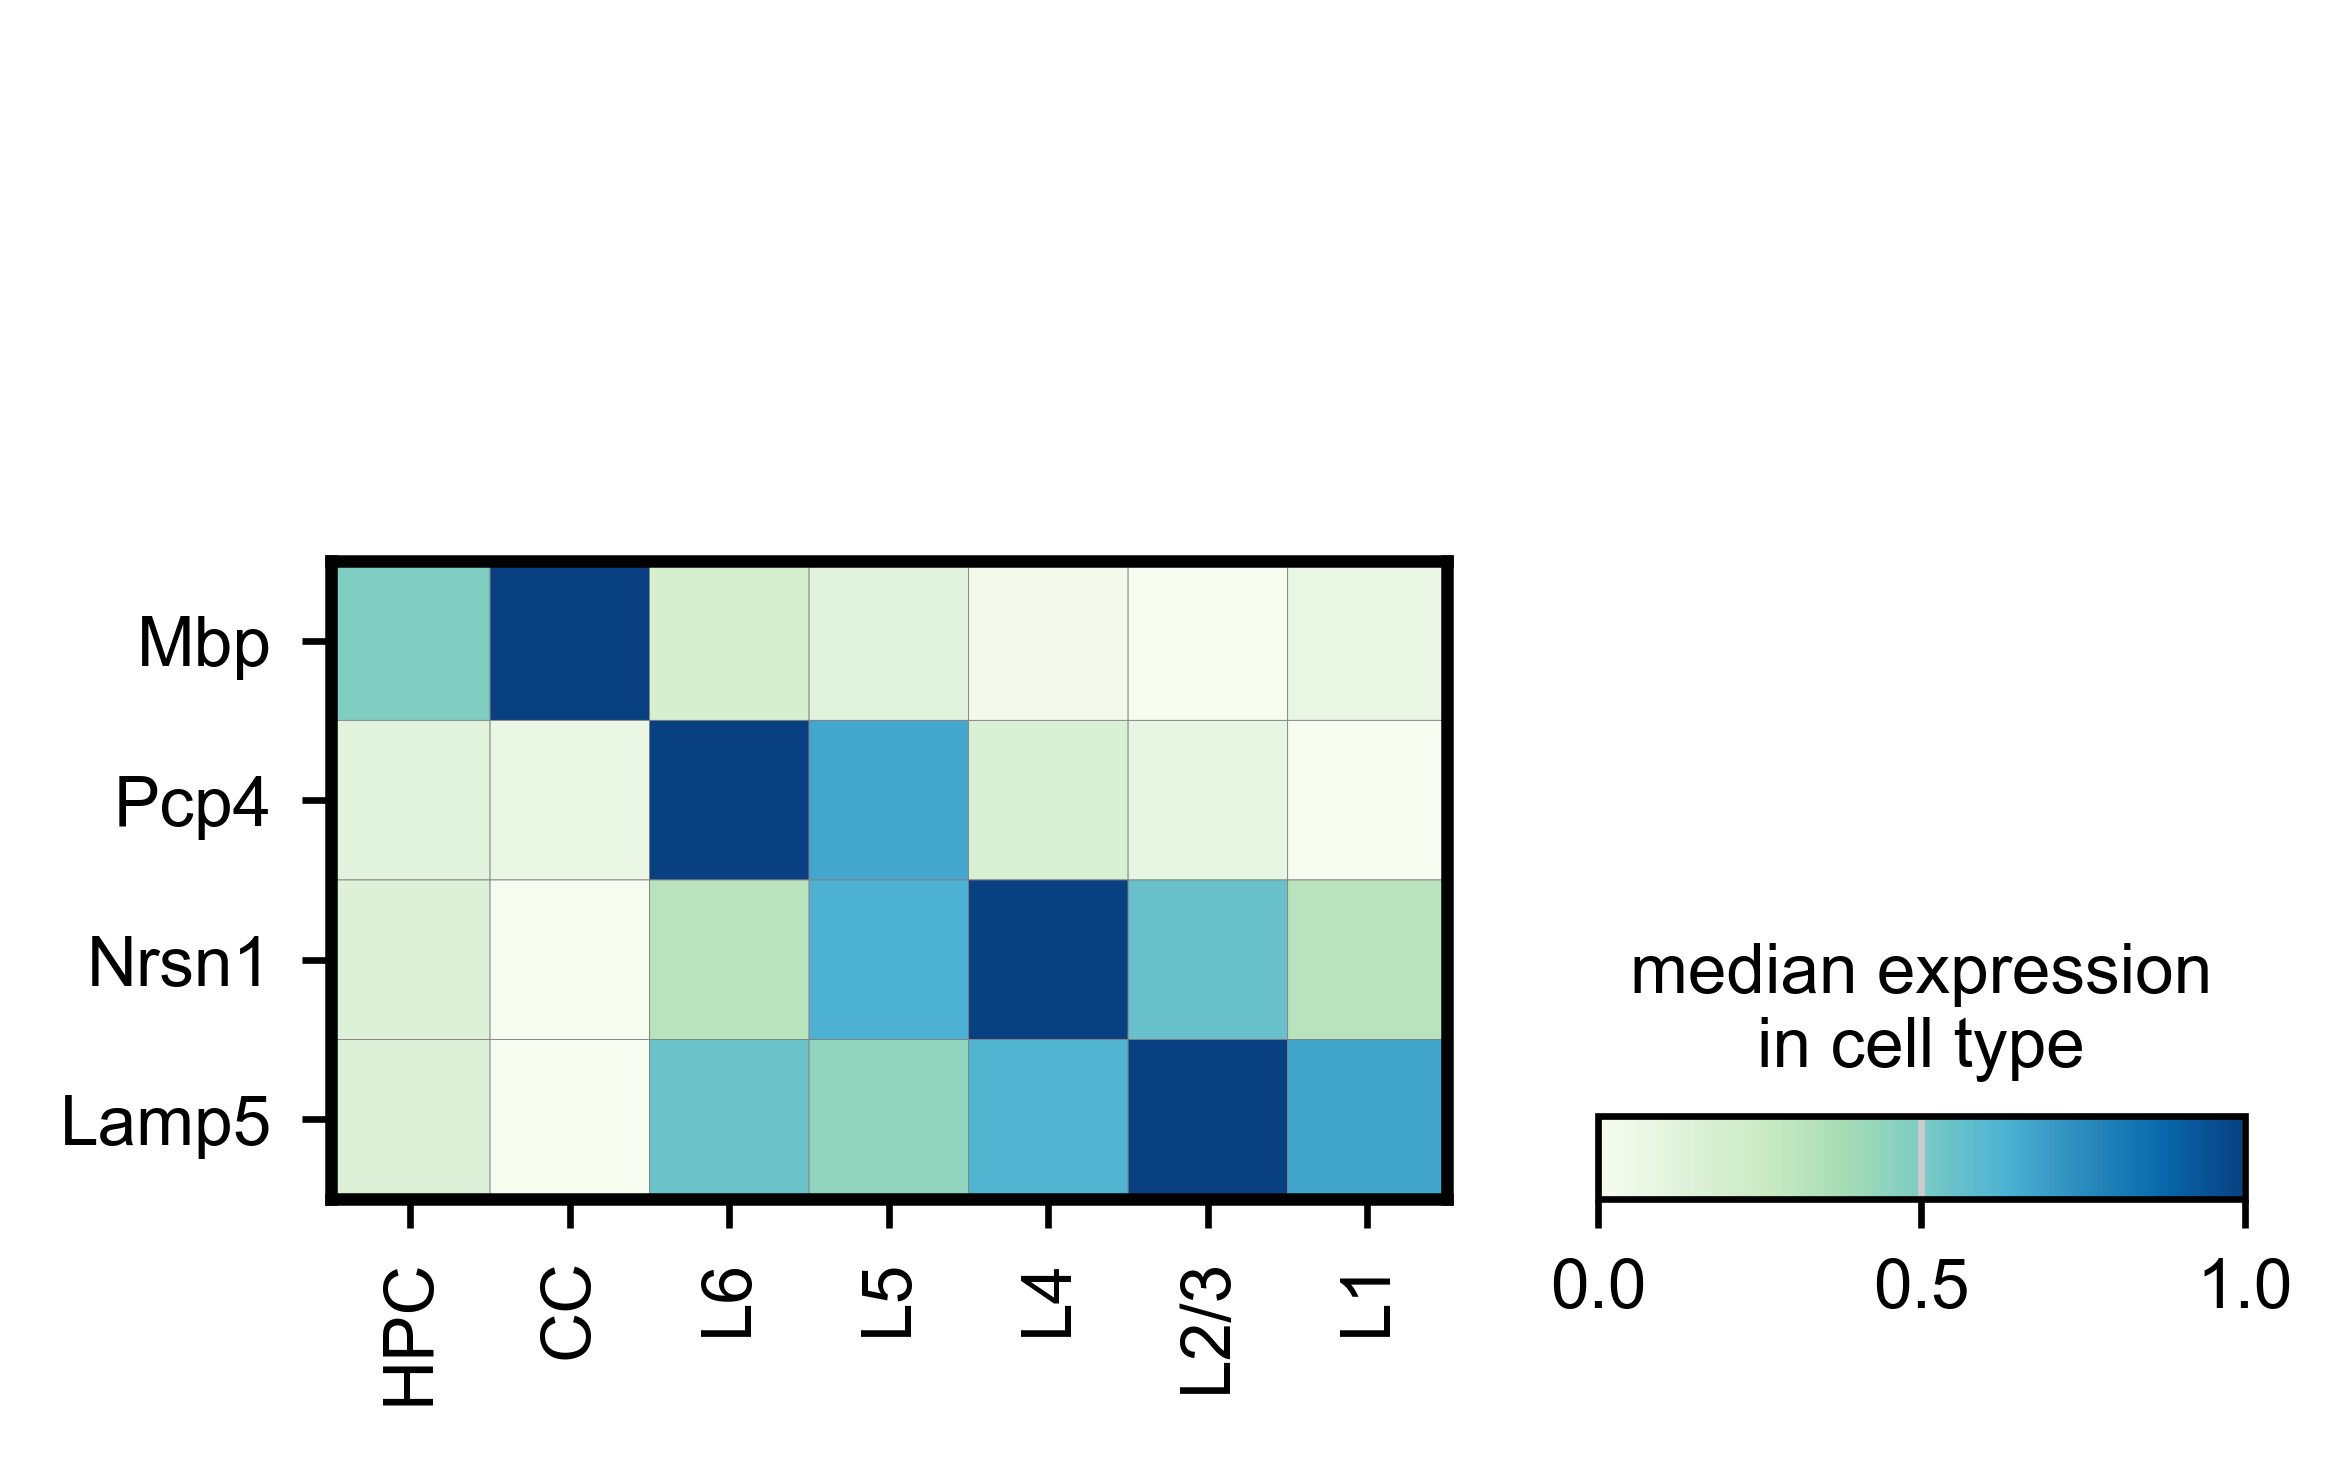

In [24]:
markers = ['Mbp','Pcp4','Nrsn1', 'Lamp5']
sc.pl.matrixplot(
    recon_obj,
    markers,
    "label",
    categories_order=['HPC','CC','L6','L5','L4', 'L2/3', 'L1'],
    dendrogram=False,
    swap_axes=True,
    cmap="GnBu",
    standard_scale="var",
    save='enclus_layer_specific_scaled',
    colorbar_title='median expression\nin cell type'
)

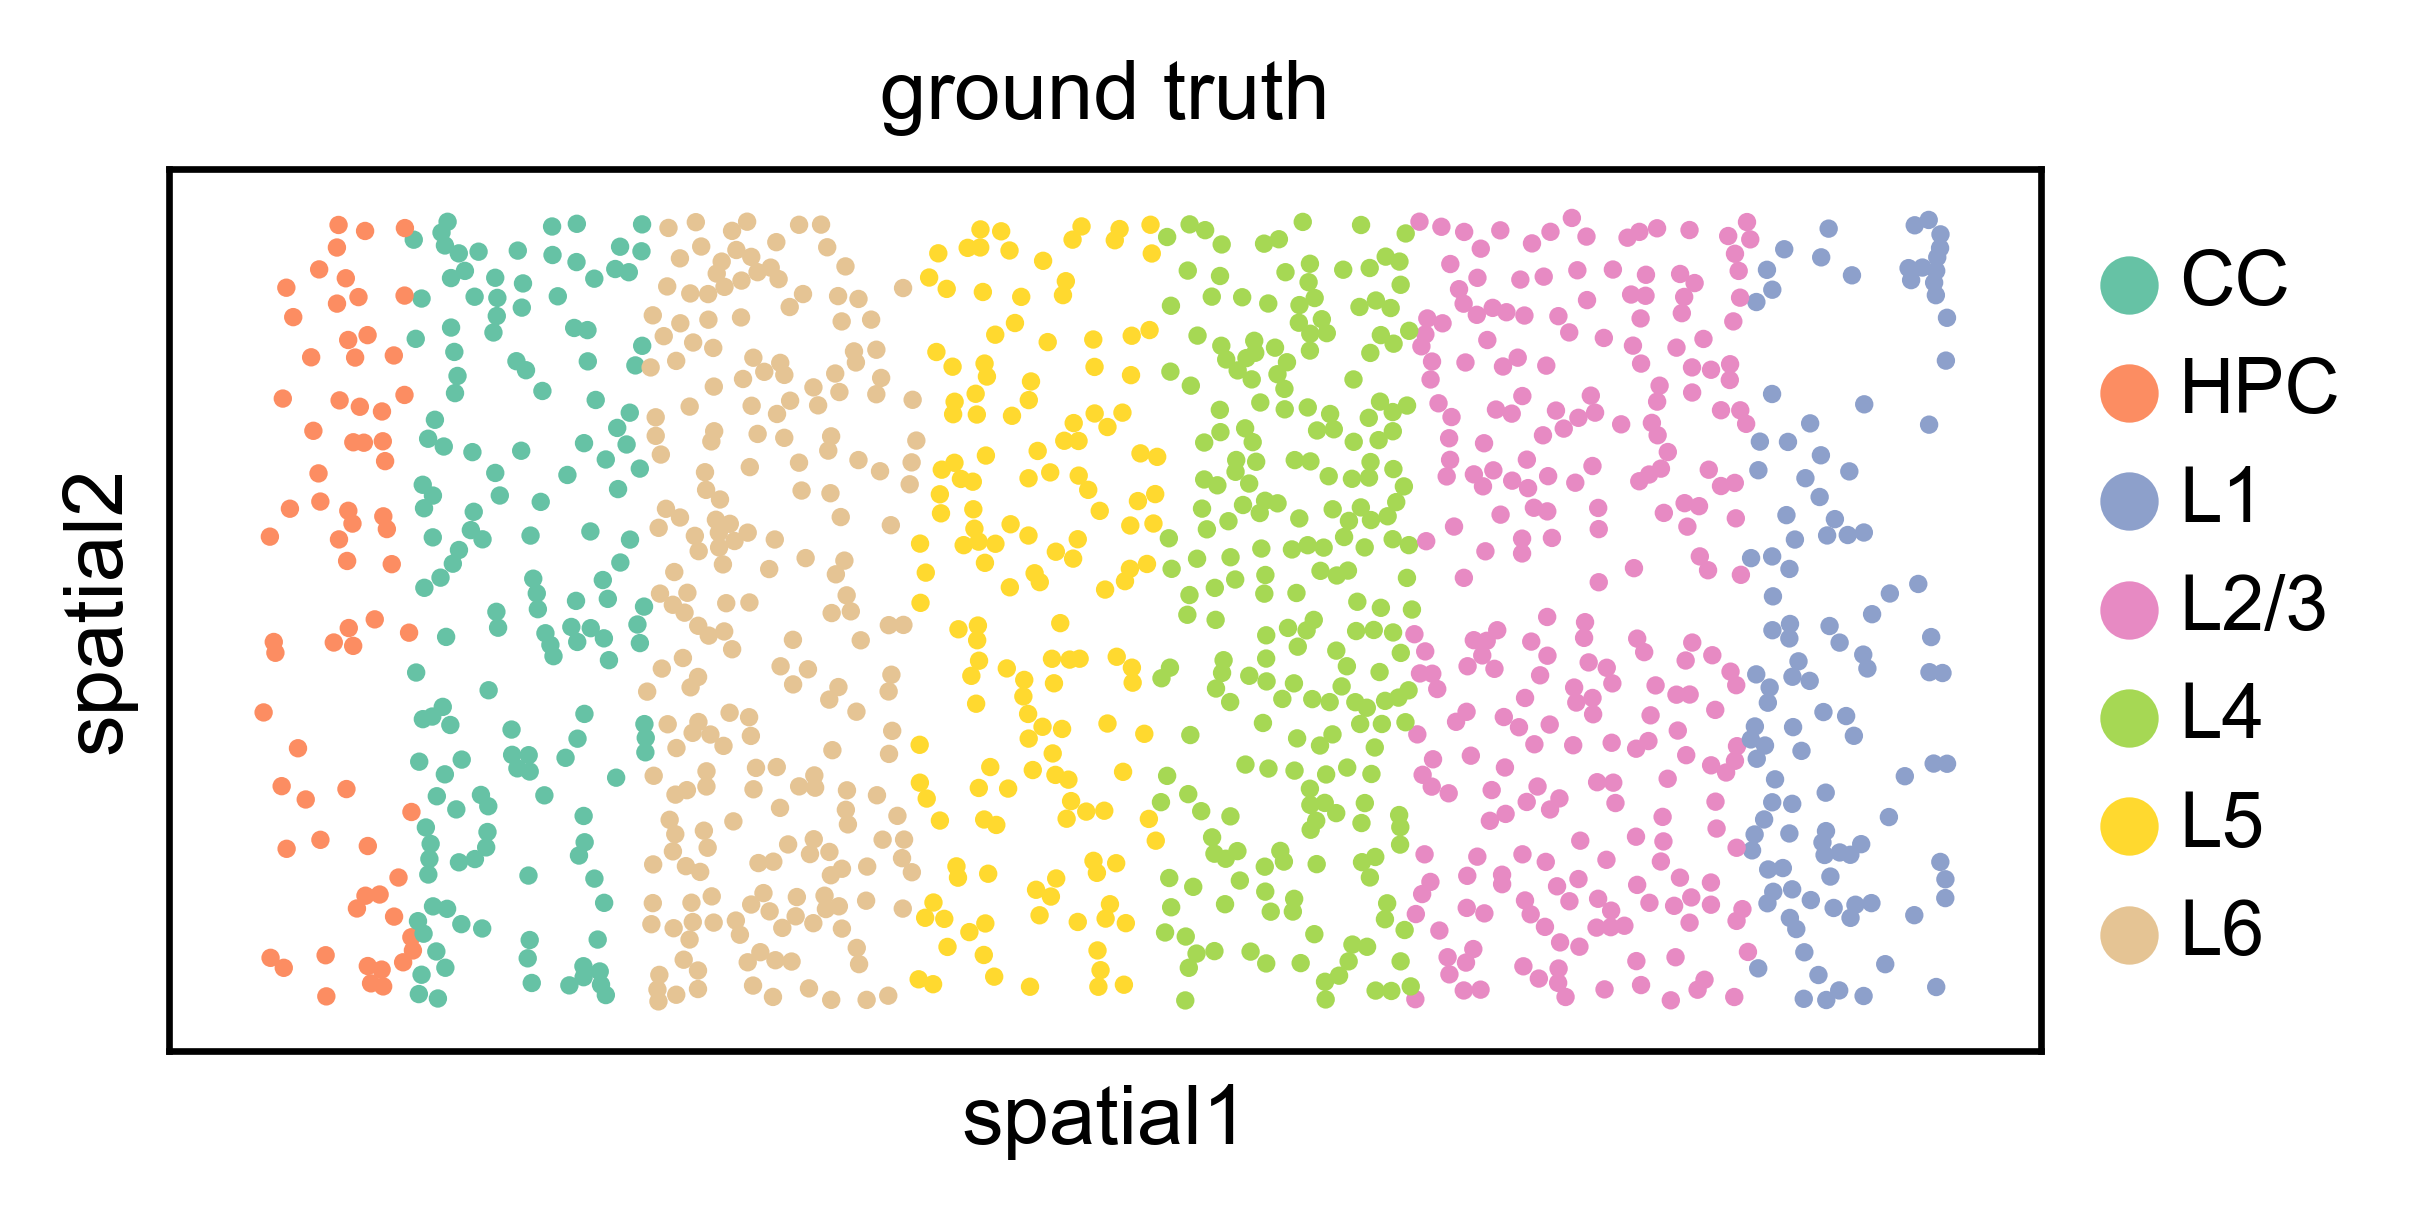

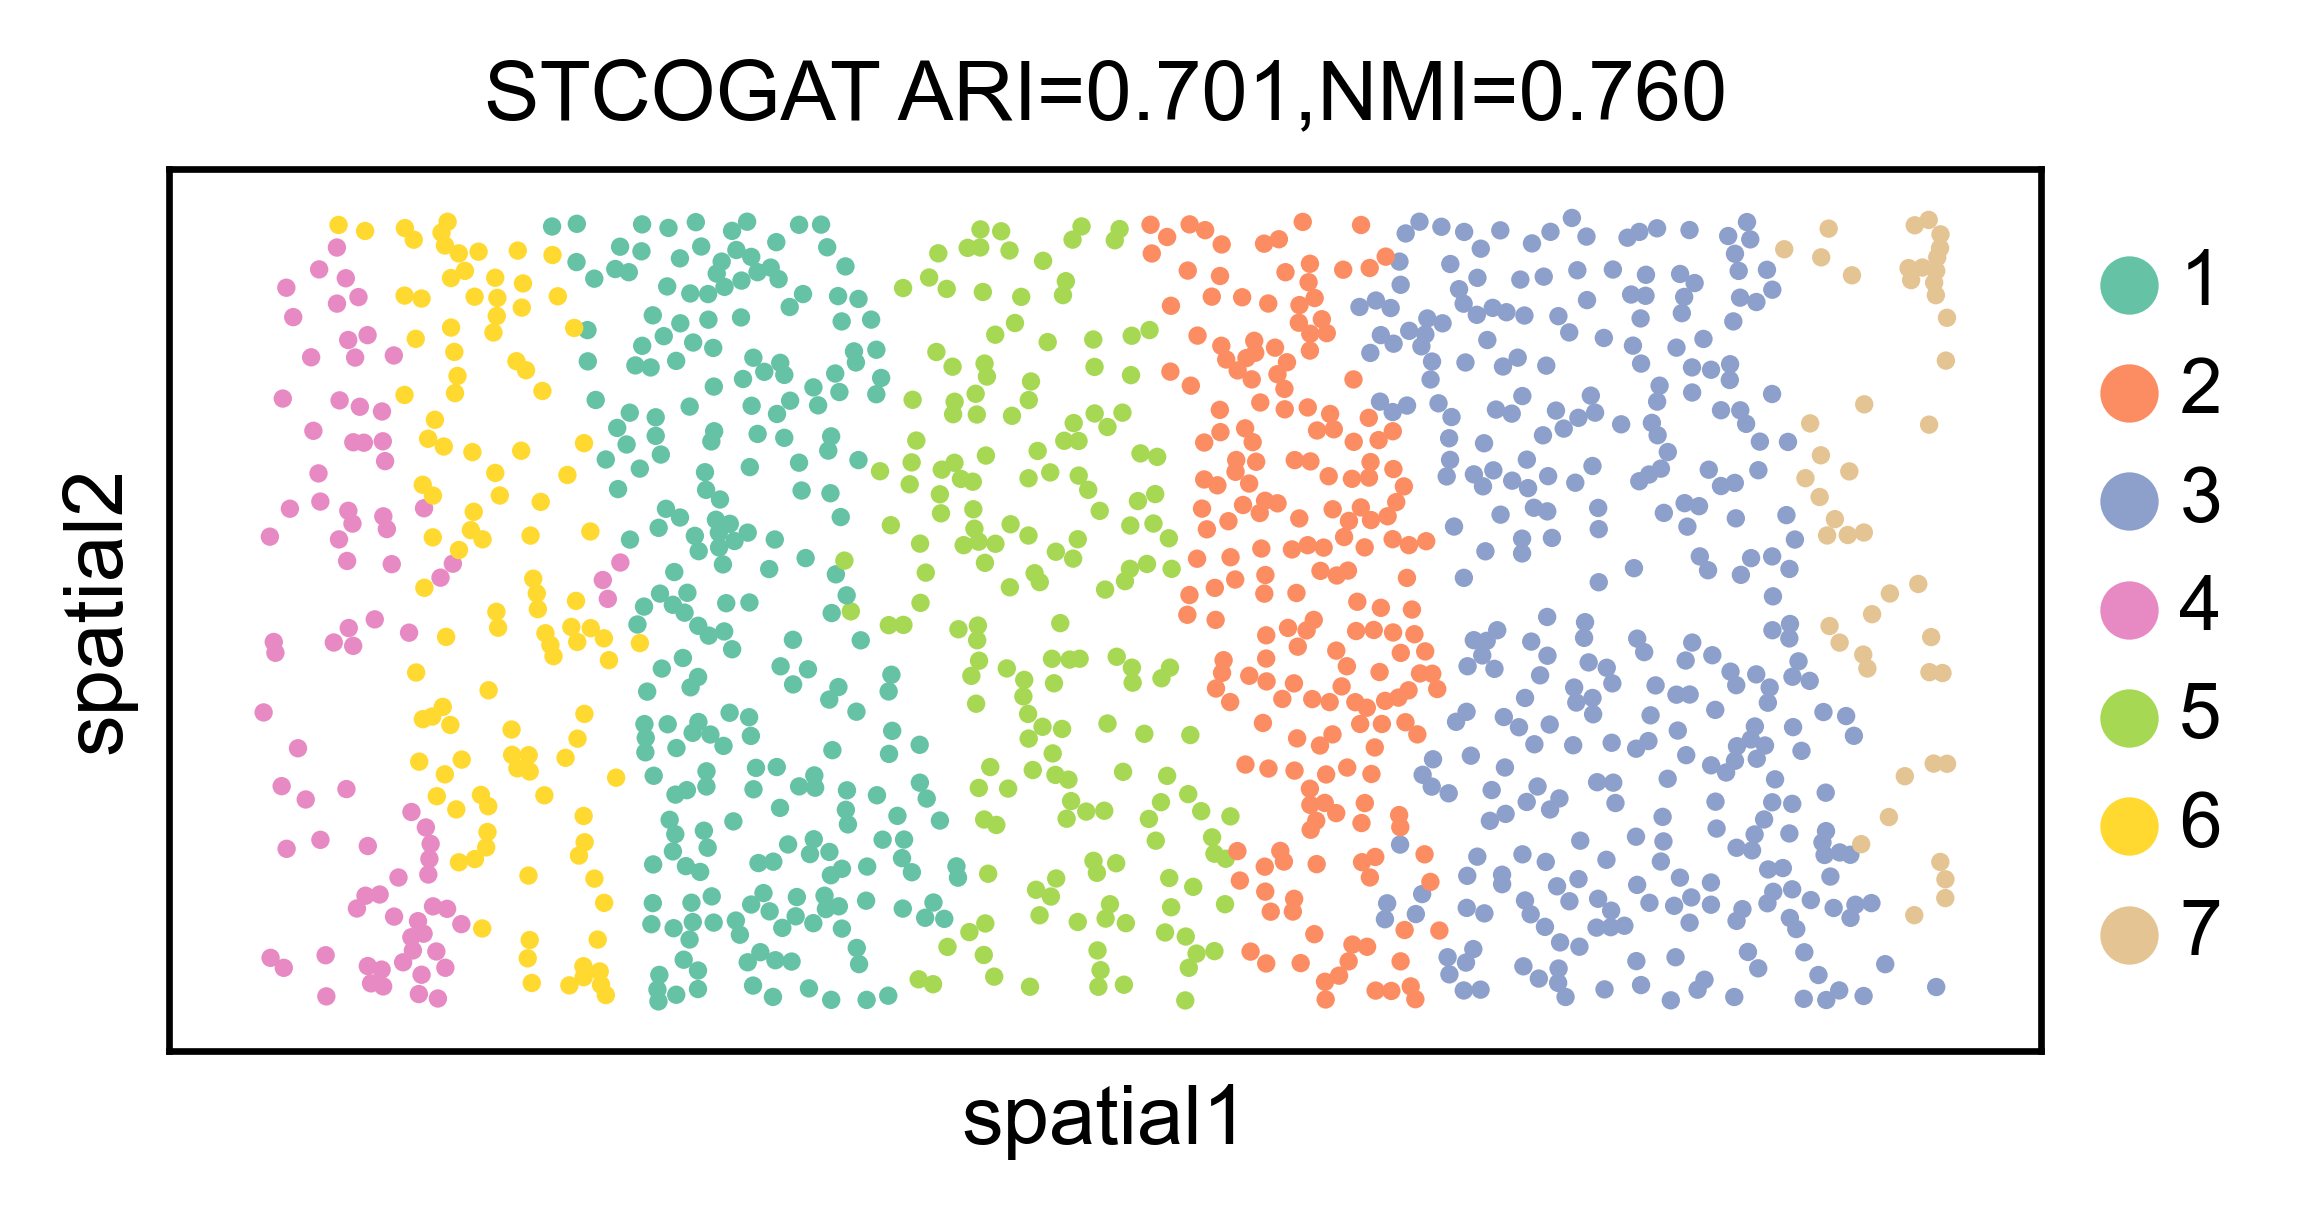

In [ ]:
import os
os.environ['R_HOME'] = '/usr/lib/R'

adata.obsm['embed'] = embedded_cells
recon_adata = adata.copy()
sc.pp.neighbors(recon_adata, use_rep='embed')
recon_adata = STCOGAT.mclust_R(recon_adata, num_cluster=7, modelNames='EEE', used_obsm='embed',random_seed=2025,obs_key='mclust_labels')

import seaborn as sns
cats = recon_adata.obs['label'].astype('category').cat.categories
rgb_values = sns.color_palette("Set2", len(cats))
color_fine = dict(zip(cats, rgb_values))

ARI_m = adjusted_rand_score(recon_adata.obs['mclust_labels'], recon_adata.obs['label'])
NMI = normalized_mutual_info_score(recon_adata.obs['mclust_labels'], recon_adata.obs['label'])
sc.pl.spatial(recon_adata, color=['label'], title=['ground truth'], spot_size=150,palette=color_fine)

cats = recon_adata.obs['mclust_labels'].astype('category').cat.categories
rgb_values = sns.color_palette("Set2", len(cats))
color_fine = dict(zip(cats, rgb_values))
sc.pl.spatial(recon_adata, color=['mclust_labels'], title=['STCOGAT ARI=%.3f,NMI=%.3f'%(ARI_m,NMI)], spot_size=150,palette=color_fine,save='ARI_mCLust.pdf')